In [1]:
import sys
sys.path.insert(0, "..")  # so `src` is importable from notebooks/

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from src.parse import OUT_DIR

# Full pipeline: `python -m src.parse` (~2 min, all 7 matches). Loading its
# already-built output here so this notebook stays fast to re-run.
matches = pd.read_csv(f"{OUT_DIR}/matches.csv")
players = pd.read_csv(f"{OUT_DIR}/players.csv")
events = pd.read_csv(f"{OUT_DIR}/events.csv", low_memory=False)
events["timestamp"] = pd.to_datetime(events["timestamp"], utc=True, format="ISO8601")

print(f"{len(matches)} matches, {len(players)} player-match rows, {len(events)} events")
matches[["match_id", "home_team_name", "away_team_name", "result"]]

7 matches, 279 player-match rows, 9961 events


,match_id,home_team_name,away_team_name,result
0,J03WMX,1. FC Köln,FC Bayern München,1:2
1,J03WN1,VfL Bochum 1848,Bayer 04 Leverkusen,3:0
2,J03WPY,Fortuna Düsseldorf,1. FC Nürnberg,0:1
3,J03WOH,Fortuna Düsseldorf,SSV Jahn Regensburg,4:0
4,J03WQQ,Fortuna Düsseldorf,FC St. Pauli,1:0
5,J03WOY,Fortuna Düsseldorf,F.C. Hansa Rostock,3:1
6,J03WR9,Fortuna Düsseldorf,1. FC Kaiserslautern,1:2


#  EDA

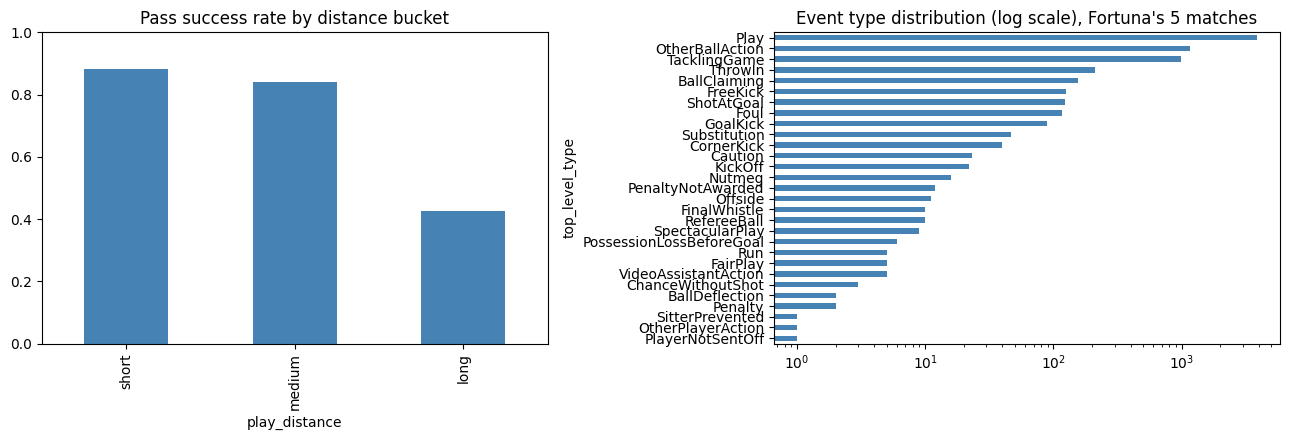

play_distance
short     0.883221
medium    0.841121
long      0.425620
Name: is_success, dtype: float64


In [2]:
TEAM_NAME = "Fortuna D\u00fcsseldorf"
team_id = players.loc[players["team_name"] == TEAM_NAME, "team_id"].iloc[0]
team_matches = matches.loc[(matches["home_team_name"] == TEAM_NAME) | (matches["away_team_name"] == TEAM_NAME), "match_id"].tolist()

is_pass = events["event_type_path"].str.endswith(("_Pass", "_Cross"))
fortuna_passes = events[is_pass & (events["team_id"] == team_id) & (events["match_id"].isin(team_matches))].copy()
fortuna_passes["is_success"] = fortuna_passes["evaluation"].isin(["successfullyCompleted", "successful"])

dist_order = ["short", "medium", "long"]
success_by_distance = fortuna_passes.groupby("play_distance")["is_success"].mean().reindex(dist_order)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
success_by_distance.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Pass success rate by distance bucket")
axes[0].set_ylim(0, 1)

counts = events[events["match_id"].isin(team_matches)]["top_level_type"].value_counts().sort_values()
counts.plot(kind="barh", ax=axes[1], color="steelblue")
axes[1].set_xscale("log")
axes[1].set_title("Event type distribution (log scale), Fortuna's 5 matches")
fig.tight_layout()
plt.show()
print(success_by_distance)

### Features, per (pass, candidate teammate)

**10 features**  `dx`, `dy`, `dist_to_passer`, `angle_to_passer`, `cand_x`, `cand_y`,
`dist_to_opp_goal`, `dist_to_own_goal`, `dist_nearest_opponent`, `n_opponents_within_5m`.

In [3]:
# Full pipeline: `python -m src.build_dataset` (~35s, all 7 matches).
pass_candidates = pd.read_parquet(f"{OUT_DIR}/pass_candidates.parquet")
print(f"{pass_candidates['pass_id'].nunique()} passes -> {len(pass_candidates)} candidate rows "
      f"({len(pass_candidates) / pass_candidates['pass_id'].nunique():.1f} candidates/pass average)")
pass_candidates.head(3)

4725 passes -> 46884 candidate rows (9.9 candidates/pass average)


,pass_id,match_id,team_id,passer_id,candidate_id,is_recipient,dx,dy,dist_to_passer,angle_to_passer,cand_x,cand_y,dist_to_opp_goal,dist_to_own_goal,dist_nearest_opponent,n_opponents_within_5m
0,18226500000011,J03WMX,DFL-CLU-00000G,DFL-OBJ-J01B8N,DFL-OBJ-0002DR,0,-41.30,-15.77,44.208403,-159.101134,-37.14,5.59,89.814129,16.345571,37.871906,0
1,18226500000011,J03WMX,DFL-CLU-00000G,DFL-OBJ-J01B8N,DFL-OBJ-0000IA,0,17.02,-3.48,17.372127,-11.555725,21.18,17.88,36.064343,75.818446,1.574071,1
2,18226500000011,J03WMX,DFL-CLU-00000G,DFL-OBJ-J01B8N,DFL-OBJ-0027G6,0,8.51,-6.28,10.576318,-36.425669,12.67,15.08,42.589145,66.891967,1.680744,1


---
# Baselines

Two ways to compare 
1. Compare with nearest teammate 
2. Compare with logistic regression model
3. Small MLP

In [4]:
def evaluate_predictions(df, prob_col="prob"):
    """df: one row per (pass, candidate), with is_recipient (0/1) and a
    probability column that sums to 1 within each pass_id group."""
    def per_pass(group):
        group = group.sort_values(prob_col, ascending=False).reset_index(drop=True)
        true_rank = group.index[group["is_recipient"] == 1][0] + 1  # 1-indexed
        p_true = group.loc[group["is_recipient"] == 1, prob_col].iloc[0]
        return pd.Series({
            "top1": int(true_rank == 1),
            "top3": int(true_rank <= 3),
            "cross_entropy": -np.log(np.clip(p_true, 1e-12, 1.0)),
        })
    per_pass_metrics = df.groupby("pass_id").apply(per_pass, include_groups=False)
    return {
        "top1_acc": per_pass_metrics["top1"].mean(),
        "top3_acc": per_pass_metrics["top3"].mean(),
        "cross_entropy": per_pass_metrics["cross_entropy"].mean(),
    }

In [5]:
from src.baselines import (
    predict_nearest_teammate, fit_predict_logreg, leave_one_match_out_cv,
)

baseline_models = {
    "nearest_teammate": lambda train_df, test_df: predict_nearest_teammate(test_df),
    "logistic_regression (dist_to_passer only)": fit_predict_logreg
}

baseline_results = []
for name, predict_fn in baseline_models.items():
    fold_results = leave_one_match_out_cv(pass_candidates, predict_fn, name)
    baseline_results.append(fold_results)
baseline_results = pd.concat(baseline_results, ignore_index=True)

baseline_summary = baseline_results.groupby("model")[["top1_acc", "top3_acc", "cross_entropy"]].agg(["mean", "std"])
baseline_summary

top1_acc            top3_acc  \
                                               mean       std      mean   
model                                                                     
logistic_regression (dist_to_passer only)  0.271789  0.038743  0.634617   
nearest_teammate                           0.271789  0.038743  0.634617   

                                                    cross_entropy            
                                                std          mean       std  
model                                                                        
logistic_regression (dist_to_passer only)  0.037621      1.945162  0.060974  
nearest_teammate                           0.037621      7.473127  0.828130

---
# model

In [6]:
import torch
import torch.nn as nn

class CandidateScorer(nn.Module):
    """Scores each candidate pass target."""

    def __init__(self, n_features, hidden=(128, 64), dropout=0.2):
        super().__init__()
        layers = []
        in_dim = n_features
        for h in hidden:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        batch, n_candidates, n_features = x.shape
        flat = x.reshape(batch * n_candidates, n_features)
        scores = self.net(flat).reshape(batch, n_candidates)
        return scores

print(CandidateScorer(n_features=10))

CandidateScorer(
  (net): Sequential(
    (0): Linear(in_features=10, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)


### Training loop



In [7]:
from src.train import passes_to_tensors, masked_scores, set_all_seeds, SEED

def train_one_fold(fit_tensors, val_tensors, n_features, max_epochs=200, patience=15, lr=1e-3, batch_size=64):
    model = CandidateScorer(n_features=n_features)
    optimiser = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    loss_fn = nn.CrossEntropyLoss()
    n_fit = fit_tensors["X"].shape[0]
    best_val_loss, best_state, epochs_without_improvement = float("inf"), None, 0

    for epoch in range(max_epochs):
        model.train()
        shuffled_idx = torch.randperm(n_fit)
        for start in range(0, n_fit, batch_size):
            batch_idx = shuffled_idx[start:start + batch_size]
            optimiser.zero_grad()
            scores = masked_scores(model, fit_tensors["X"][batch_idx], fit_tensors["mask"][batch_idx])
            loss = loss_fn(scores, fit_tensors["target"][batch_idx])
            loss.backward()
            optimiser.step()

        model.eval()
        with torch.no_grad():
            val_scores = masked_scores(model, val_tensors["X"], val_tensors["mask"])
            val_loss = loss_fn(val_scores, val_tensors["target"]).item()

        if val_loss < best_val_loss - 1e-4:
            best_val_loss = val_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                break 

    model.load_state_dict(best_state)
    model.eval()
    return model

In [8]:
from src.train import NN_FEATURE_COLS, tensors_to_long_df

def train_predict_one_fold(train_df, test_df, max_candidates):

    rng = np.random.default_rng(SEED)
    train_pass_ids = train_df["pass_id"].unique()
    rng.shuffle(train_pass_ids)
    n_val = max(1, int(len(train_pass_ids) * 0.15))
    val_ids, fit_ids = set(train_pass_ids[:n_val]), set(train_pass_ids[n_val:])

    fit_tensors = passes_to_tensors(train_df[train_df["pass_id"].isin(fit_ids)], max_candidates)
    val_tensors = passes_to_tensors(train_df[train_df["pass_id"].isin(val_ids)], max_candidates,
                                     fit_tensors["feature_means"], fit_tensors["feature_stds"])
    test_tensors = passes_to_tensors(test_df, max_candidates,
                                      fit_tensors["feature_means"], fit_tensors["feature_stds"])

    model = train_one_fold(fit_tensors, val_tensors, n_features=len(NN_FEATURE_COLS))
    with torch.no_grad():
        test_probs = torch.softmax(masked_scores(model, test_tensors["X"], test_tensors["mask"]), dim=1)
    predictions = tensors_to_long_df(test_tensors["pass_ids"], test_tensors["candidate_ids"], test_probs, test_tensors["mask"])
    return predictions.merge(test_df[["pass_id", "candidate_id", "is_recipient"]], on=["pass_id", "candidate_id"], how="left")

set_all_seeds(SEED)
print(f"seed={SEED}")
max_candidates = pass_candidates.groupby("pass_id").size().max()

HELD_OUT_MATCH = "J03WMX"
demo_fold_train_df = pass_candidates[pass_candidates["match_id"] != HELD_OUT_MATCH]
demo_fold_test_df = pass_candidates[pass_candidates["match_id"] == HELD_OUT_MATCH]
one_fold_predictions = train_predict_one_fold(demo_fold_train_df, demo_fold_test_df, max_candidates)

print(f"one fold, held out = {HELD_OUT_MATCH}:")
print(evaluate_predictions(one_fold_predictions))

seed=42
one fold, held out = J03WMX:
{'top1_acc': np.float64(0.4918444165621079), 'top3_acc': np.float64(0.8331242158092849), 'cross_entropy': np.float64(1.4533244677196482)}


### Full comparison table (all 7 folds)

In [9]:
nn_fold_results = pd.read_csv(f"{OUT_DIR}/nn_fold_results_all_matches.csv")
nn_summary = nn_fold_results[["top1_acc", "top3_acc", "cross_entropy"]].agg(["mean", "std"])

final_row = pd.DataFrame({
    ("top1_acc", "mean"): [nn_summary.loc["mean", "top1_acc"]], ("top1_acc", "std"): [nn_summary.loc["std", "top1_acc"]],
    ("top3_acc", "mean"): [nn_summary.loc["mean", "top3_acc"]], ("top3_acc", "std"): [nn_summary.loc["std", "top3_acc"]],
    ("cross_entropy", "mean"): [nn_summary.loc["mean", "cross_entropy"]], ("cross_entropy", "std"): [nn_summary.loc["std", "cross_entropy"]],
}, index=["neural_net (7-fold CV)"])
pd.concat([baseline_summary, final_row])

top1_acc            top3_acc  \
                                               mean       std      mean   
logistic_regression (dist_to_passer only)  0.271789  0.038743  0.634617   
nearest_teammate                           0.271789  0.038743  0.634617   
neural_net (7-fold CV)                     0.429462  0.034702  0.780427   

                                                    cross_entropy            
                                                std          mean       std  
logistic_regression (dist_to_passer only)  0.037621      1.945162  0.060974  
nearest_teammate                           0.037621      7.473127  0.828130  
neural_net (7-fold CV)                     0.028842      1.592092  0.072444

---
# Visualisation

Demo match: **J03WOH** 

In [10]:
from src.pitch import draw_pitch
from src.viz import get_pass_snapshot, draw_players, draw_pass_arrow, draw_prediction_overlay
from src.build_dataset import MatchPositions, build_kickoff_lookup

DEMO_MATCH = "J03WOY"
second_half_cutoff, team_left_by_match_half = build_kickoff_lookup(events)
match_pos = MatchPositions(DEMO_MATCH)
team_of_in_match = players.loc[players["match_id"] == DEMO_MATCH].set_index("person_id")["team_id"].to_dict()

demo_train_df = pass_candidates[pass_candidates["match_id"] != DEMO_MATCH]
demo_test_df = pass_candidates[pass_candidates["match_id"] == DEMO_MATCH]
demo_predictions = train_predict_one_fold(demo_train_df, demo_test_df, max_candidates)
demo_predictions["is_top1"] = demo_predictions.groupby("pass_id")["prob"].transform("max") == demo_predictions["prob"]
print("model trained on the other 6 matches, predicting on J03WOH (never seen)")

model trained on the other 6 matches, predicting on J03WOH (never seen)


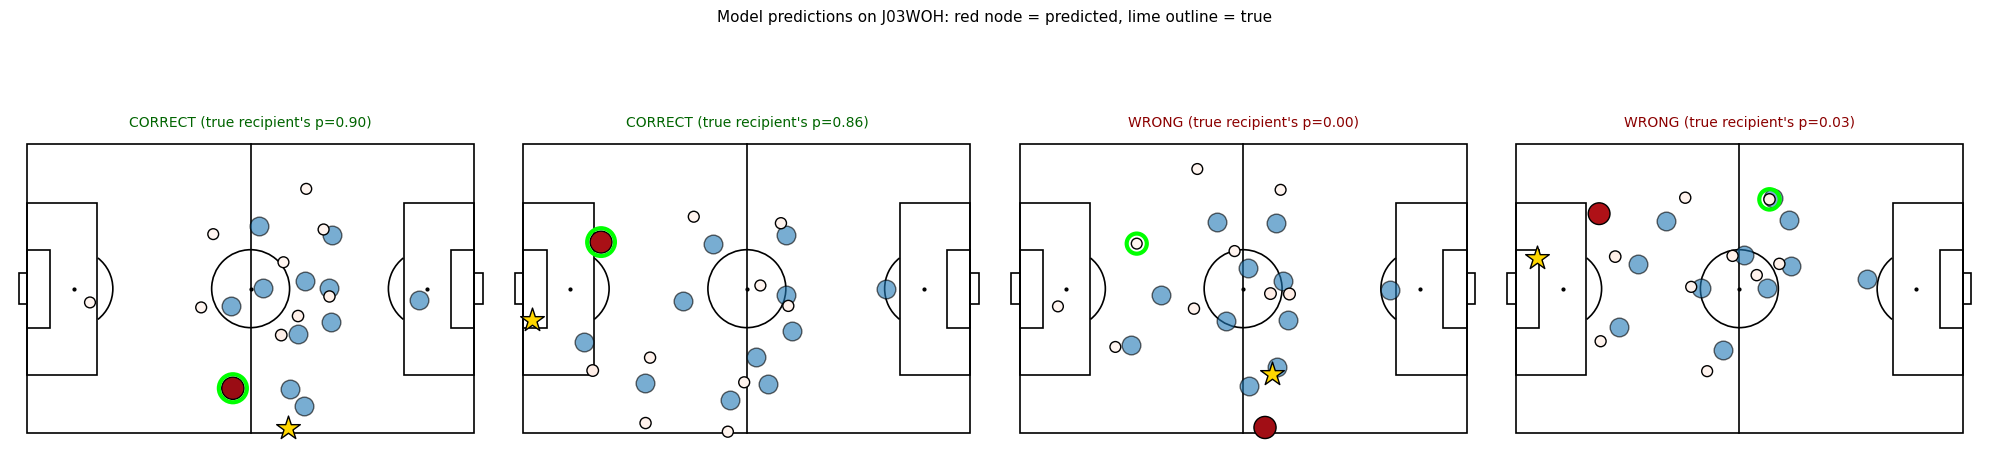

In [13]:
correct_ids = demo_predictions[demo_predictions["is_top1"] & (demo_predictions["is_recipient"] == 1)].sort_values("prob", ascending=False)["pass_id"].head(2).tolist()
wrong_ids = demo_predictions[demo_predictions["is_top1"] & (demo_predictions["is_recipient"] == 0)].sort_values("prob", ascending=False)["pass_id"].head(2).tolist()

fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
for ax, pass_id, label, colour in (
    [(axes[i], pid, "CORRECT", "darkgreen") for i, pid in enumerate(correct_ids)]
    + [(axes[i + 2], pid, "WRONG", "darkred") for i, pid in enumerate(wrong_ids)]
):
    draw_pitch(ax)
    pass_row = events[events["event_id"] == pass_id].iloc[0]
    snapshot, _, _ = get_pass_snapshot(pass_row, match_pos, team_of_in_match, second_half_cutoff, team_left_by_match_half)
    this_pred = demo_predictions[demo_predictions["pass_id"] == pass_id]
    true_prob = this_pred.loc[this_pred["is_recipient"] == 1, "prob"].iloc[0]
    draw_prediction_overlay(ax, snapshot, this_pred, 220, 60)
    ax.set_title(f"{label} (true recipient's p={true_prob:.2f})", fontsize=10, color=colour)
fig.suptitle("Model predictions on J03WOH: red node = predicted, lime outline = true", fontsize=11)
fig.tight_layout()
plt.show()